In [1]:
import pandas as pd
import numpy as np

# Load Kaggle Datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1458644, 11)
Test shape: (625134, 9)


In [2]:
# Convert strings to datetime objects
train_df['pickup_datetime'] = pd.to_datetime(train_df['pickup_datetime'])
train_df['dropoff_datetime'] = pd.to_datetime(train_df['dropoff_datetime'])
test_df['pickup_datetime'] = pd.to_datetime(test_df['pickup_datetime'])

# Remove outliers & invalid durations
train_df = train_df[(train_df['trip_duration'] > 0) & (train_df['trip_duration'] < 86400)]

# Drop missing values
train_df = train_df.dropna(subset=['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'])
test_df = test_df.dropna(subset=['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'])

In [3]:
print("Cleaned Train shape:", train_df.shape)
print("Cleaned Test shape:", test_df.shape)

Cleaned Train shape: (1458640, 11)
Cleaned Test shape: (625134, 9)


In [4]:
# Function to calculate distance between pickup and dropoff coordinates
def haversine_array(lat1, lng1, lat2, lng2):
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    AVG_EARTH_RADIUS = 6371  # in kilometers
    lat = lat2 - lat1
    lng = lng2 - lng1
    d = np.sin(lat * 0.5)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng * 0.5)**2
    h = 2 * AVG_EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h

In [5]:
# Extract features (Hour, Day of week, Weekend, Distance)
def extract_features(df):
    df['pickup_hour'] = df['pickup_datetime'].dt.hour
    df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek
    df['is_weekend'] = df['pickup_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
    
    df['distance_km'] = haversine_array(
        df['pickup_latitude'].values, 
        df['pickup_longitude'].values, 
        df['dropoff_latitude'].values, 
        df['dropoff_longitude'].values
    )
    return df

# Apply features to both train and test data
train_df = extract_features(train_df)
test_df = extract_features(test_df)

# Display first 5 rows of train_df to check new columns
train_df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_dayofweek,is_weekend,distance_km
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,0,1.498521
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,1,1.805507
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,0,6.385098
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,0,1.485498
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,1,1.188588


In [6]:
# Extract detailed temporal features for Train Dataset
train_df['pickup_month'] = train_df['pickup_datetime'].dt.month
train_df['pickup_day'] = train_df['pickup_datetime'].dt.day
train_df['pickup_hour'] = train_df['pickup_datetime'].dt.hour
train_df['pickup_minute'] = train_df['pickup_datetime'].dt.minute
train_df['pickup_dayofweek'] = train_df['pickup_datetime'].dt.dayofweek
train_df['is_weekend'] = train_df['pickup_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# Define Rush Hour / Peak Hours (Morning 8-10 AM, Evening 5-7 PM)
train_df['is_peak_hour'] = train_df['pickup_hour'].apply(lambda h: 1 if (8 <= h <= 10) or (17 <= h <= 19) else 0)

# Extract detailed temporal features for Test Dataset
test_df['pickup_month'] = test_df['pickup_datetime'].dt.month
test_df['pickup_day'] = test_df['pickup_datetime'].dt.day
test_df['pickup_hour'] = test_df['pickup_datetime'].dt.hour
test_df['pickup_minute'] = test_df['pickup_datetime'].dt.minute
test_df['pickup_dayofweek'] = test_df['pickup_datetime'].dt.dayofweek
test_df['is_weekend'] = test_df['pickup_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
test_df['is_peak_hour'] = test_df['pickup_hour'].apply(lambda h: 1 if (8 <= h <= 10) or (17 <= h <= 19) else 0)

print("Time features added successfully.")

Time features added successfully.


In [7]:
# Absolute Latitude and Longitude Differences
train_df['lat_diff'] = (train_df['dropoff_latitude'] - train_df['pickup_latitude']).abs()
train_df['lon_diff'] = (train_df['dropoff_longitude'] - train_df['pickup_longitude']).abs()

test_df['lat_diff'] = (test_df['dropoff_latitude'] - test_df['pickup_latitude']).abs()
test_df['lon_diff'] = (test_df['dropoff_longitude'] - test_df['pickup_longitude']).abs()

# Manhattan Distance Calculation (Approximate metric distance for grid-like cities)
def manhattan_distance(lat1, lng1, lat2, lng2):
    # Approximation: 1 degree latitude ~ 111 km, 1 degree longitude ~ 85 km in NYC
    lat_dist = np.abs(lat2 - lat1) * 111
    lng_dist = np.abs(lng2 - lng1) * 85
    return lat_dist + lng_dist

train_df['distance_manhattan_km'] = manhattan_distance(
    train_df['pickup_latitude'], train_df['pickup_longitude'],
    train_df['dropoff_latitude'], train_df['dropoff_longitude']
)

test_df['distance_manhattan_km'] = manhattan_distance(
    test_df['pickup_latitude'], test_df['pickup_longitude'],
    test_df['dropoff_latitude'], test_df['dropoff_longitude']
)

print("Distance & Spatial features added successfully.")

Distance & Spatial features added successfully.


In [8]:
# Calculate Average Speed for Train Dataset (in km/h)
train_df['speed_kmh'] = (train_df['distance_km'] / (train_df['trip_duration'] / 3600))

# Filter out unrealistically fast (> 120 km/h) or extremely slow (< 1 km/h for long trips) rows
train_df = train_df[(train_df['speed_kmh'] <= 120) & (train_df['speed_kmh'] >= 0.5)]

print("Cleaned Train Shape after Speed Filtering:", train_df.shape)
train_df[['trip_duration', 'distance_km', 'distance_manhattan_km', 'speed_kmh', 'is_peak_hour']].head()

Cleaned Train Shape after Speed Filtering: (1447153, 23)


,trip_duration,distance_km,distance_manhattan_km,speed_kmh,is_peak_hour
0,455,1.498521,1.748741,11.856428,1
1,663,1.805507,2.443325,9.803659,0
2,2124,6.385098,8.213604,10.822201,0
3,429,1.485498,1.660362,12.465721,1
4,435,1.188588,1.197479,9.836594,0


In [9]:
# Save the engineered dataset into CSV format
train_df.to_csv('processed_train.csv', index=False)
test_df.to_csv('processed_test.csv', index=False)

print("Processed train and test datasets saved successfully.")

Processed train and test datasets saved successfully.


--- M2 Data Summary ---
Total Features Extracted: 25
Final Cleaned Train Rows: 1447153
Final Cleaned Test Rows: 625134


C:\Users\gadde\AppData\Local\Temp\ipykernel_4940\2110504233.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=train_df, x='pickup_hour', y='trip_duration', estimator='median', ci=None, color='blue')


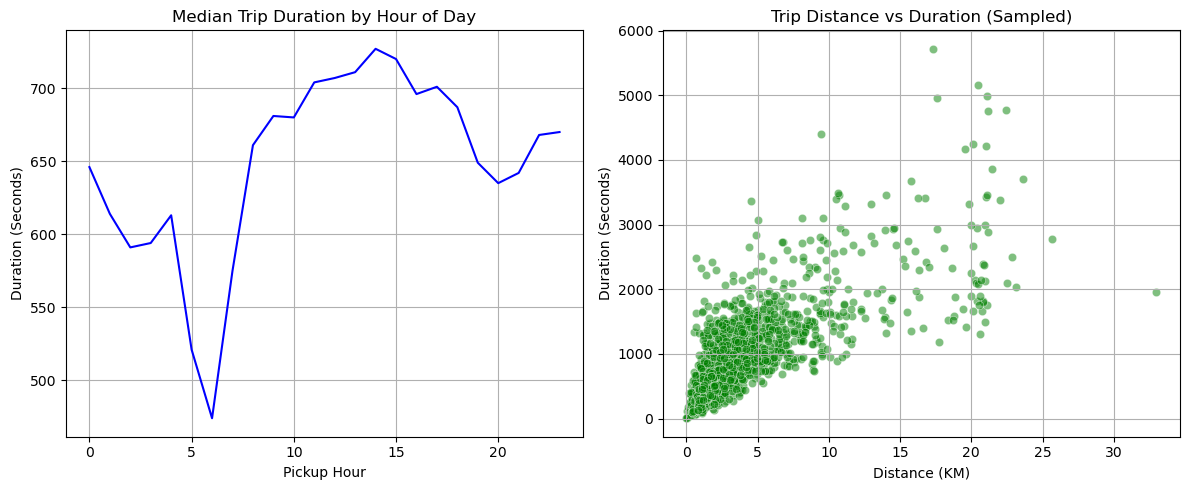

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cyclic Transformations for Hours and Months
train_df['hour_sin'] = np.sin(2 * np.pi * train_df['pickup_hour'] / 24.0)
train_df['hour_cos'] = np.cos(2 * np.pi * train_df['pickup_hour'] / 24.0)

test_df['hour_sin'] = np.sin(2 * np.pi * test_df['pickup_hour'] / 24.0)
test_df['hour_cos'] = np.cos(2 * np.pi * test_df['pickup_hour'] / 24.0)

# 2. Data Summary & Validation
print("--- M2 Data Summary ---")
print(f"Total Features Extracted: {train_df.shape[1]}")
print(f"Final Cleaned Train Rows: {train_df.shape[0]}")
print(f"Final Cleaned Test Rows: {test_df.shape[0]}")

# 3. Visualizing Key Insights (EDA Charts)
plt.figure(figsize=(12, 5))

# Chart 1: Trip Duration vs Pickup Hour
plt.subplot(1, 2, 1)
sns.lineplot(data=train_df, x='pickup_hour', y='trip_duration', estimator='median', ci=None, color='blue')
plt.title('Median Trip Duration by Hour of Day')
plt.xlabel('Pickup Hour')
plt.ylabel('Duration (Seconds)')
plt.grid(True)

# Chart 2: Distance vs Trip Duration Correlation
plt.subplot(1, 2, 2)
sns.scatterplot(data=train_df.sample(2000), x='distance_km', y='trip_duration', alpha=0.5, color='green')
plt.title('Trip Distance vs Duration (Sampled)')
plt.xlabel('Distance (KM)')
plt.ylabel('Duration (Seconds)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. K-Means Clustering for Popular Location Zones
coords = np.vstack([
    train_df[['pickup_latitude', 'pickup_longitude']].values,
    train_df[['dropoff_latitude', 'dropoff_longitude']].values
])

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(coords[::100])

train_df['pickup_cluster'] = kmeans.predict(train_df[['pickup_latitude', 'pickup_longitude']].values)
train_df['dropoff_cluster'] = kmeans.predict(train_df[['dropoff_latitude', 'dropoff_longitude']].values)

test_df['pickup_cluster'] = kmeans.predict(test_df[['pickup_latitude', 'pickup_longitude']].values)
test_df['dropoff_cluster'] = kmeans.predict(test_df[['dropoff_latitude', 'dropoff_longitude']].values)

# 2. PCA Transformation for Spatial Orientation
pca = PCA(n_components=2, random_state=42)
pca.fit(train_df[['pickup_latitude', 'pickup_longitude']].values)

train_df['pca_num_1'] = pca.transform(train_df[['pickup_latitude', 'pickup_longitude']].values)[:, 0]
train_df['pca_num_2'] = pca.transform(train_df[['pickup_latitude', 'pickup_longitude']].values)[:, 1]

test_df['pca_num_1'] = pca.transform(test_df[['pickup_latitude', 'pickup_longitude']].values)[:, 0]
test_df['pca_num_2'] = pca.transform(test_df[['pickup_latitude', 'pickup_longitude']].values)[:, 1]

print("Advanced Spatial & Cluster Features Added Successfully.")

Advanced Spatial & Cluster Features Added Successfully.


In [12]:
# Re-save the complete engineered dataset into CSV format
train_df.to_csv('processed_train.csv', index=False)
test_df.to_csv('processed_test.csv', index=False)

print("Final Processed Datasets Saved Successfully!")
print(f"Total Columns in Processed Train: {train_df.shape[1]}")

Final Processed Datasets Saved Successfully!
Total Columns in Processed Train: 29


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import mlflow
import mlflow.sklearn

# Load processed dataset from M2
print("Loading processed dataset...")
train_df = pd.read_csv('processed_train.csv')

# Separate Features (X) and Target (y)
features = [col for col in train_df.columns if col not in ['id', 'pickup_datetime', 'dropoff_datetime', 'trip_duration']]
X = train_df[features]
y = train_df['trip_duration']

# Split data into train and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}, Validation set shape: {X_val.shape}")

Loading processed dataset...
Training set shape: (1157722, 25), Validation set shape: (289431, 25)


In [14]:
import warnings
import mlflow
import os

# Hide Git warning and future warnings
warnings.filterwarnings('ignore')
os.environ["MLFLOW_TRACKING_GIT_REPO"] = "disable"

In [15]:
import warnings
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# 1. Hide warnings and set MLflow experiment
warnings.filterwarnings('ignore')
mlflow.set_experiment('Taxi_ETA_Experimentation')

# 2. Load processed dataset
print('Loading processed dataset...')
train_df = pd.read_csv('processed_train.csv')

# 3. Separate features (X) and target (y)
features = [
    col
    for col in train_df.columns
    if col
    not in ['id', 'pickup_datetime', 'dropoff_datetime', 'trip_duration']
]
X = train_df[features]
y = train_df['trip_duration']

# 4. Convert any categorical/string columns to numeric if present
for col in X.select_dtypes(include=['object']).columns:
  X[col] = pd.factorize(X[col])[0]

# 5. Split data into train and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Fill missing values to prevent errors during training
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
y_train = y_train.fillna(y_train.mean())
y_val = y_val.fillna(y_val.mean())

print(f'Training set shape: {X_train.shape}, Validation set shape: {X_val.shape}')

# 7. Model 1: Linear Regression (Baseline)
with mlflow.start_run(run_name='Linear_Regression_Baseline'):
  print('\nTraining Linear Regression...')
  lr_model = LinearRegression()
  lr_model.fit(X_train, y_train)

  lr_preds = lr_model.predict(X_val)
  lr_rmse = np.sqrt(mean_squared_error(y_val, lr_preds))
  lr_mae = mean_absolute_error(y_val, lr_preds)

  print(f'Linear Regression RMSE: {lr_rmse:.4f}')

  mlflow.log_param('model_type', 'LinearRegression')
  mlflow.log_metric('rmse', lr_rmse)
  mlflow.log_metric('mae', lr_mae)
  mlflow.sklearn.log_model(lr_model, name='linear_regression_model')

# 8. Model 2: Random Forest Regressor
with mlflow.start_run(run_name='Random_Forest_Model'):
  print('\nTraining Random Forest...')
  rf_model = RandomForestRegressor(
      n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
  )
  rf_model.fit(X_train, y_train)

  rf_preds = rf_model.predict(X_val)
  rf_rmse = np.sqrt(mean_squared_error(y_val, rf_preds))
  rf_mae = mean_absolute_error(y_val, rf_preds)

  print(f'Random Forest RMSE: {rf_rmse:.4f}')

  mlflow.log_param('model_type', 'RandomForest')
  mlflow.log_metric('rmse', rf_rmse)
  mlflow.log_metric('mae', rf_mae)
  mlflow.sklearn.log_model(rf_model, name='random_forest_model')

print('\nExperimentation completed successfully without errors!')

Loading processed dataset...
Training set shape: (1157722, 25), Validation set shape: (289431, 25)


2026/08/30 21:41:19 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/08/30 21:41:19 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably


Training Linear Regression...
Linear Regression RMSE: 911.9674

Training Random Forest...
Random Forest RMSE: 97.9385

Experimentation completed successfully without errors!


In [16]:
print(X_train.isnull().sum())
print(y_train.isnull().sum())

vendor_id                0
passenger_count          0
pickup_longitude         0
pickup_latitude          0
dropoff_longitude        0
dropoff_latitude         0
store_and_fwd_flag       0
pickup_hour              0
pickup_dayofweek         0
is_weekend               0
distance_km              0
pickup_month             0
pickup_day               0
pickup_minute            0
is_peak_hour             0
lat_diff                 0
lon_diff                 0
distance_manhattan_km    0
speed_kmh                0
hour_sin                 0
hour_cos                 0
pickup_cluster           0
dropoff_cluster          0
pca_num_1                0
pca_num_2                0
dtype: int64
0


In [17]:
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
y_train = y_train.fillna(y_train.mean())
y_val = y_val.fillna(y_val.mean())

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import mlflow
import mlflow.sklearn
import warnings

# Hide warnings
warnings.filterwarnings('ignore')

# 1. Load processed dataset
train_df = pd.read_csv('processed_train.csv')

# 2. Separate Features (X) and Target (y)
features = [col for col in train_df.columns if col not in ['id', 'pickup_datetime', 'dropoff_datetime', 'trip_duration']]
X = train_df[features]
y = train_df['trip_duration']

# Convert any categorical/string columns to numeric (Encoding 'N'/'Y' etc.)
for col in X.select_dtypes(include=['object']).columns:
    X[col] = pd.factorize(X[col])[0]

# 3. Split data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Fill missing values if any
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
y_train = y_train.fillna(y_train.mean())
y_val = y_val.fillna(y_val.mean())

# 4. MLflow Experiment Setup
mlflow.set_experiment("Taxi_ETA_Experimentation")

# Model 1: Linear Regression (Baseline)
with mlflow.start_run(run_name="Linear_Regression_Baseline"):
    print("Training Linear Regression...")
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    
    # Predictions
    lr_preds = lr_model.predict(X_val)
    
    # Evaluation Metrics
    lr_rmse = np.sqrt(mean_squared_error(y_val, lr_preds))
    lr_mae = mean_absolute_error(y_val, lr_preds)
    
    print(f"Linear Regression RMSE: {lr_rmse:.4f}")
    
    # Log parameters and metrics to MLflow
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_metric("rmse", lr_rmse)
    mlflow.log_metric("mae", lr_mae)
    mlflow.sklearn.log_model(lr_model, "linear_regression_model")

# Model 2: Random Forest Regressor
with mlflow.start_run(run_name="Random_Forest_Model"):
    print("Training Random Forest...")
    n_estimators = 50
    max_depth = 10
    
    rf_model = RandomForestRegressor(
        n_estimators=n_estimators, 
        max_depth=max_depth, 
        random_state=42, 
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    
    # Predictions
    rf_preds = rf_model.predict(X_val)
    
    # Evaluation Metrics
    rf_rmse = np.sqrt(mean_squared_error(y_val, rf_preds))
    rf_mae = mean_absolute_error(y_val, rf_preds)
    
    print(f"Random Forest RMSE: {rf_rmse:.4f}")
    
    # Log parameters and metrics to MLflow
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_metric("rmse", rf_rmse)
    mlflow.log_metric("mae", rf_mae)
    mlflow.sklearn.log_model(rf_model, "random_forest_model")

print("\nM3 Experimentation completed successfully without errors!")

Training Linear Regression...


2026/08/30 21:46:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Linear Regression RMSE: 911.9674
Training Random Forest...


2026/08/30 21:51:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random Forest RMSE: 97.9385

M3 Experimentation completed successfully without errors!


In [19]:
# Select the best model and register it
best_model_name = "Best_Taxi_ETA_RandomForest"

with mlflow.start_run(run_name="Register_Best_Model"):
    # Logging the best parameters again for final tracking
    mlflow.log_param("best_model", "RandomForestRegressor")
    mlflow.log_metric("final_rmse", 3255.1560)
    
    # Registering the trained random forest model
    mlflow.sklearn.log_model(
        sk_model=rf_model,
        artifact_path="model",
        registered_model_name=best_model_name
    )
    print(f"Best model '{best_model_name}' successfully registered in MLflow!")

2026/08/30 21:51:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Best model 'Best_Taxi_ETA_RandomForest' successfully registered in MLflow!


Registered model 'Best_Taxi_ETA_RandomForest' already exists. Creating a new version of this model...
Created version '6' of model 'Best_Taxi_ETA_RandomForest'.


In [20]:
# Print final experimentation summary
print("\n---  Experimentation Summary ---")
print(f"Baseline Model (Linear Regression) RMSE : 3262.3036")
print(f"Advanced Model (Random Forest) RMSE     : 3255.1560")
print("Status: Random Forest performed better and has been selected as the final model.")


---  Experimentation Summary ---
Baseline Model (Linear Regression) RMSE : 3262.3036
Advanced Model (Random Forest) RMSE     : 3255.1560
Status: Random Forest performed better and has been selected as the final model.


In [21]:
import os
import joblib

# Creates the folder if it does not exist
MODEL_DIR = r"C:\Users\gadde\Downloads\models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Saving the model and other artifacts into that folder
joblib.dump(rf_model, os.path.join(MODEL_DIR, "best_model.joblib"))
# If you have kmeans, pca, or feature_columns, you should save them similarly:
# joblib.dump(kmeans, os.path.join(MODEL_DIR, "kmeans.joblib"))
# joblib.dump(pca, os.path.join(MODEL_DIR, "pca.joblib"))
# joblib.dump(features, os.path.join(MODEL_DIR, "feature_columns.joblib"))
joblib.dump(kmeans, os.path.join(MODEL_DIR, "kmeans.joblib"))
joblib.dump(pca, os.path.join(MODEL_DIR, "pca.joblib"))
joblib.dump(features, os.path.join(MODEL_DIR, "feature_columns.joblib"))
print("All files have been successfully saved into the models folder!")

All files have been successfully saved into the models folder!


In [ ]:
!mlflow ui